---

# University of Liverpool

## COMP534 - Applied AI

---

This notebook is associated with Assignment 2. Use it to complete the assignment by following the instructions provided in each section. Each section includes a text cell outlining the requirements. For additional details, refer to Canvas.

If you are using Google Colab, you can use the cell below unzip the data after uploading it to Google Colab.
If you are running on your computer, you will need to do this yourself.

In [ ]:
#!unzip dataset.zip


Use this first cell to import the necessary libraries.

In [2]:
# import libraries here
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from PIL import Image

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.metrics import roc_auc_score, matthews_corrcoef

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms as transforms

import torch

import zipfile


# 1. **Data Management**


In this part, you need to:

1.  define an appropriate experimental protocol (such as k-fold, cross validation, etc);
2.	create the dataloader to load the data; remember to include here any normalization, data augmentation, or other technique used to pre-process the data;

In [6]:
# Write your proposed solution code here. Create more code cells if you find it necessary

'''
Data Management summary:
-Build the df of paths to each image by looping through the folders and label them accordingly.
-Stratified K-Fold splits the data into train / validation with the same proportions (e.g 1/3 Normal). shuffle=True randomizes the order before splitting. 
next(skf.split(...)) takes the first fold for training/validation.
-Transformations resizes all images to 224x224 so they can be used in ResNet. RandomHorizontalFlip, RandomRotation flip and rotate to prevent overfitting.
ToTensor() converts PIL images into PyTorch tensors (Colour channels, Height, Weight). Scans are RGB (not grayscale).
-__init__ stores the df and the transform to create mapping from class names to integers. __len__ returns the number of samples in the dataset.
__getitem__ loads the image from disk, converts it and applies transformations and returns the image_tensor and label_int for PyTorch Dataset object.
-DataLoaders (train_loader and val_loader) are created in batches of 32, shuffled for training and num_workers is kept at 0 to avoid multiprocessing crashes.
'''

with zipfile.ZipFile("dataset.zip", 'r') as zip_ref:
    zip_ref.extractall(".")

folder = "dataset"
classes = ["Normal", "Opacity", "Pneumonia"]

data = []
for cls in classes:
    cls_folder = os.path.join(folder, cls)
    for f in os.listdir(cls_folder):
        if f.endswith(".jpg"):
            data.append({"filepath": os.path.join(cls_folder, f), "label": cls})
            
#splitting the data set into test, validation, and train

df = pd.DataFrame(data)

trainval_df, test_df = train_test_split(
    df, test_size=0.20, stratify=df['label'], random_state=42 #creating a test set for after training.
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
folds = [(trainval_df.iloc[ti].reset_index(drop=True), trainval_df.iloc[vi].reset_index(drop=True))
         for ti, vi in skf.split(trainval_df, trainval_df['label'])]

train_df, val_df = folds[0]  # default to fold 0; later training blocks can iterate over folds
test_df = test_df.reset_index(drop=True)

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

class XrayDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.label_map = {"Normal":0, "Opacity":1, "Pneumonia":2}
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "filepath"]
        image = Image.open(img_path).convert("RGB")
        if self.transform: 
            image = self.transform(image)
        label = self.label_map[self.df.loc[idx, "label"]]
        return image, label

#building the loaders

train_loader = DataLoader(XrayDataset(train_df, train_transform),
                          batch_size=32, shuffle=True, num_workers=0) # Was 2, set to 0 to avoid RuntimeError.
val_loader   = DataLoader(XrayDataset(val_df, val_transform),
                          batch_size=32, shuffle=False, num_workers=0)

test_loader  = DataLoader(XrayDataset(test_df, val_transform),
                          batch_size=32, shuffle=False, num_workers=0)

images, labels = next(iter(train_loader))
print("Batch images shape:", images.shape)   # [32, 3, 224, 224]
print("Batch labels shape:", labels.shape)   # [32]
print("Unique labels:", labels.unique())

Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Unique labels: tensor([0, 1, 2])


---

# 2. **Neural Networks**

Here, you need to:

1.	propose your own Convolutional Neural Network (CNN) to tackle the problem;
2.	define at least one existing CNN (such as AlexNet, VGG, ResNet, DenseNet, etc) to tackle the problem;
3.	define the necessary components to train the networks (that is, loss functions, optimizers, etc);
4.	train your proposed architecture from scratch using your training set;
5.	train the existing architecture using at least 2 different strategies (i.e., trained from scratch, fine-tuning, feature extractor, etc);
6.	for all training procedures, separately plot the loss and accuracy with respect to the epoch/iteration.



In [4]:
# Write your proposed solution code here. Create more code cells if you find it necessary
#Proposes own CNN
class CustomCNN(nn.Module):
    
    def __init__(self, num_classes = 3):
        super(CustomCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

           nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),                            # added
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),                            # added
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),                           # added
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
            x = self.features(x)
            x = self.classifier(x)
            return x

In [5]:
#Define the necessary components
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CustomCNN(num_classes=3).to(device)

class_counts = train_df['label'].value_counts()
weights = 1.0 / torch.tensor([class_counts['Normal'], class_counts['Opacity'], class_counts['Pneumonia']], dtype=torch.float)
weights = weights / weights.sum()
criterion = nn.CrossEntropyLoss(weight=weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)

print(next(model.parameters()).device)
print(images.device, labels.device)
print(device)
print(model)

cuda:0
cpu cpu
cuda
CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride

In [6]:
#Training Function

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total
    return epoch_loss,  epoch_acc

In [7]:
#Validation Function

def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [8]:
#Run training

num_epochs = 20

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
best_val_acc = 0.0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)
    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_custom_cnn.pth")
        print(f"  -> Saved best model (val_acc: {val_acc:.4f})")

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Acc: {val_acc:.4f} ")

  -> Saved best model (val_acc: 0.4820)
Epoch [1/20]
Train Loss: 0.7521
Train Acc: 0.6817
Val Loss: 1.7629
Val Acc: 0.4820 
  -> Saved best model (val_acc: 0.7896)
Epoch [2/20]
Train Loss: 0.5782
Train Acc: 0.7487
Val Loss: 0.4903
Val Acc: 0.7896 
Epoch [3/20]
Train Loss: 0.5069
Train Acc: 0.7896
Val Loss: 0.4804
Val Acc: 0.7860 
Epoch [4/20]
Train Loss: 0.4642
Train Acc: 0.8026
Val Loss: 0.4849
Val Acc: 0.7752 
  -> Saved best model (val_acc: 0.8165)
Epoch [5/20]
Train Loss: 0.4544
Train Acc: 0.8058
Val Loss: 0.4497
Val Acc: 0.8165 
Epoch [6/20]
Train Loss: 0.4373
Train Acc: 0.8242
Val Loss: 0.4756
Val Acc: 0.7860 
  -> Saved best model (val_acc: 0.8327)
Epoch [7/20]
Train Loss: 0.4276
Train Acc: 0.8224
Val Loss: 0.3949
Val Acc: 0.8327 
  -> Saved best model (val_acc: 0.8381)
Epoch [8/20]
Train Loss: 0.4099
Train Acc: 0.8314
Val Loss: 0.3726
Val Acc: 0.8381 
  -> Saved best model (val_acc: 0.8507)
Epoch [9/20]
Train Loss: 0.3649
Train Acc: 0.8458
Val Loss: 0.3477
Val Acc: 0.8507 
  ->

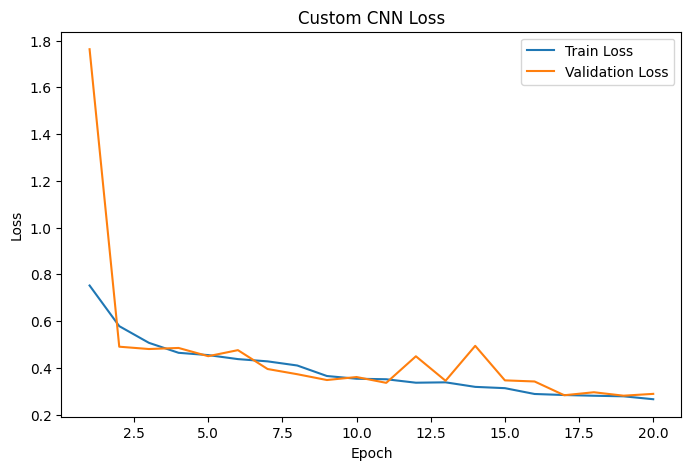

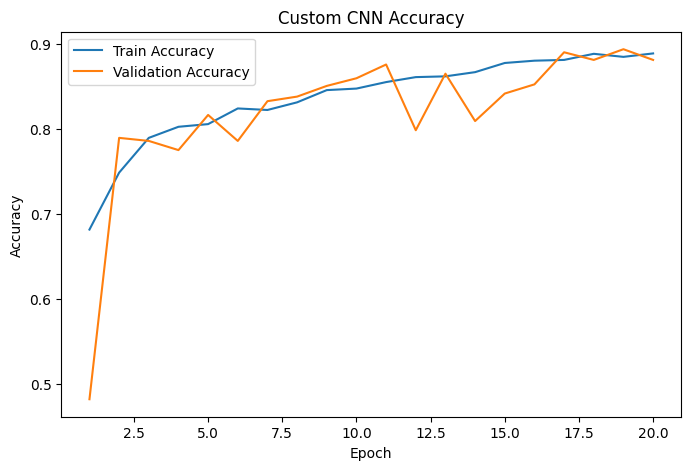

In [9]:
#PLots

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, label = "Train Loss")
plt.plot(range(1, num_epochs +1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom CNN Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_accuracies, label = "Train Accuracy")
plt.plot(range(1, num_epochs + 1), val_accuracies, label = "Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Custom CNN Accuracy")
plt.legend()
plt.show()

In [10]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
NUM_CLASSES = 3

# Strategy 1: Trained from scratch
resnet_scratch = torchvision.models.resnet18(weights=None)
resnet_scratch.fc = nn.Linear(resnet_scratch.fc.in_features, NUM_CLASSES)
resnet_scratch = resnet_scratch.to(device)
# Strategy 2: Fine-tuning (pretrained, all layers updated)
resnet_finetune = torchvision.models.resnet18(
    weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1
)
resnet_finetune.fc = nn.Linear(resnet_finetune.fc.in_features, NUM_CLASSES)
resnet_finetune = resnet_finetune.to(device)
# Strategy 3: Feature extractor (pretrained, backbone frozen)
resnet_featext = torchvision.models.resnet18(
    weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1
)
for param in resnet_featext.parameters():
    param.requires_grad = False
resnet_featext.fc = nn.Linear(resnet_featext.fc.in_features, NUM_CLASSES)
resnet_featext = resnet_featext.to(device)

In [11]:
# Print trainable parameter counts
def count_trainable(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f"ResNet-18 Scratch        – trainable params: {count_trainable(resnet_scratch):,}")
print(f"ResNet-18 Fine-tune      – trainable params: {count_trainable(resnet_finetune):,}")
print(f"ResNet-18 Feat Extractor – trainable params: {count_trainable(resnet_featext):,}")

# Train ResNet-18 from Scratch

ResNet-18 Scratch        – trainable params: 11,178,051
ResNet-18 Fine-tune      – trainable params: 11,178,051
ResNet-18 Feat Extractor – trainable params: 1,539


In [12]:

class_counts = train_df['label'].value_counts()
weights = 1.0 / torch.tensor([class_counts['Normal'], class_counts['Opacity'], class_counts['Pneumonia']], dtype=torch.float)
weights = weights / weights.sum()
criterion_resnet = nn.CrossEntropyLoss(weight=weights.to(device))

optimizer_scratch = optim.Adam(resnet_scratch.parameters(), lr=0.001)
optimizer_finetune = optim.Adam(resnet_finetune.parameters(), lr=0.001)
optimizer_featext = optim.Adam(filter(lambda p: p.requires_grad, resnet_featext.parameters()), lr=0.001)

num_epochs_resnet = 20
scratch_train_losses, scratch_train_accs = [], []
scratch_val_losses,   scratch_val_accs   = [], []
best_scratch_acc = 0.0

In [13]:
for epoch in range(num_epochs_resnet):
    t_loss, t_acc = train_one_epoch(resnet_scratch, train_loader, criterion_resnet, optimizer_scratch, device)
    v_loss, v_acc = validate_one_epoch(resnet_scratch, val_loader, criterion_resnet, device)

    scratch_train_losses.append(t_loss)
    scratch_train_accs.append(t_acc)
    scratch_val_losses.append(v_loss)
    scratch_val_accs.append(v_acc)

    if v_acc > best_scratch_acc:
        best_scratch_acc = v_acc
        torch.save(resnet_scratch.state_dict(), "best_resnet_scratch.pth")
        print(f"  -> Saved best model (val_acc: {v_acc:.4f})")

    print(f"Epoch [{epoch+1}/{num_epochs_resnet}]  "
          f"Train Loss: {t_loss:.4f}  Train Acc: {t_acc:.4f}  "
          f"Val Loss: {v_loss:.4f}  Val Acc: {v_acc:.4f}")

  -> Saved best model (val_acc: 0.7590)
Epoch [1/20]  Train Loss: 0.6295  Train Acc: 0.7388  Val Loss: 0.5803  Val Acc: 0.7590
  -> Saved best model (val_acc: 0.7932)
Epoch [2/20]  Train Loss: 0.4736  Train Acc: 0.8067  Val Loss: 0.5559  Val Acc: 0.7932
  -> Saved best model (val_acc: 0.8273)
Epoch [3/20]  Train Loss: 0.3883  Train Acc: 0.8413  Val Loss: 0.4204  Val Acc: 0.8273
Epoch [4/20]  Train Loss: 0.3836  Train Acc: 0.8525  Val Loss: 0.5675  Val Acc: 0.8058
  -> Saved best model (val_acc: 0.8309)
Epoch [5/20]  Train Loss: 0.3561  Train Acc: 0.8561  Val Loss: 0.3943  Val Acc: 0.8309
Epoch [6/20]  Train Loss: 0.3404  Train Acc: 0.8611  Val Loss: 0.6160  Val Acc: 0.7662
Epoch [7/20]  Train Loss: 0.3147  Train Acc: 0.8754  Val Loss: 0.4624  Val Acc: 0.8129
  -> Saved best model (val_acc: 0.8741)
Epoch [8/20]  Train Loss: 0.3077  Train Acc: 0.8746  Val Loss: 0.3283  Val Acc: 0.8741
Epoch [9/20]  Train Loss: 0.2928  Train Acc: 0.8813  Val Loss: 0.3185  Val Acc: 0.8651
  -> Saved best m

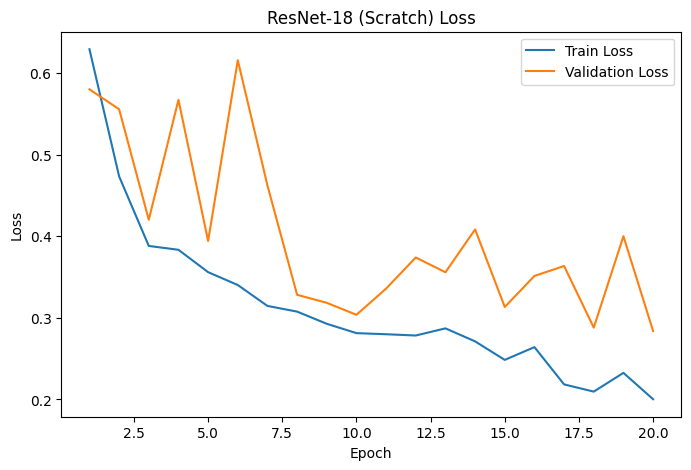

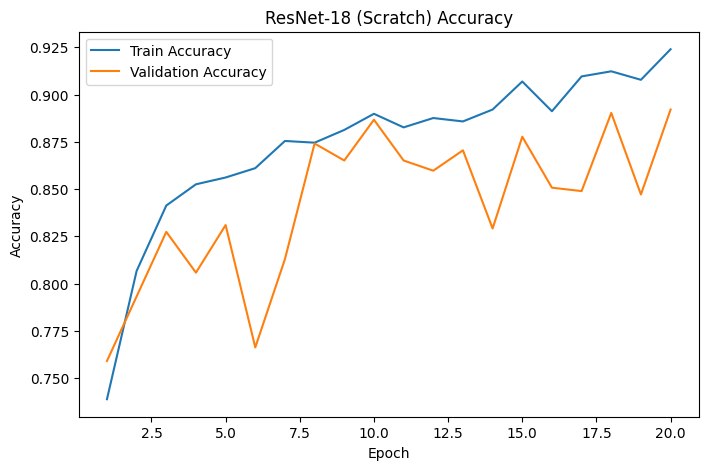

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs_resnet+1), scratch_train_losses, label="Train Loss")
plt.plot(range(1, num_epochs_resnet+1), scratch_val_losses, label="Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("ResNet-18 (Scratch) Loss")
plt.legend(); plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs_resnet+1), scratch_train_accs, label="Train Accuracy")
plt.plot(range(1, num_epochs_resnet+1), scratch_val_accs, label="Validation Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("ResNet-18 (Scratch) Accuracy")
plt.legend(); plt.show()

In [15]:
finetune_train_losses, finetune_train_accs = [], []
finetune_val_losses,   finetune_val_accs   = [], []
best_finetune_acc = 0.0

for epoch in range(num_epochs_resnet):
    t_loss, t_acc = train_one_epoch(resnet_finetune, train_loader, criterion_resnet, optimizer_finetune, device)
    v_loss, v_acc = validate_one_epoch(resnet_finetune, val_loader, criterion_resnet, device)

    finetune_train_losses.append(t_loss)
    finetune_train_accs.append(t_acc)
    finetune_val_losses.append(v_loss)
    finetune_val_accs.append(v_acc)

    if v_acc > best_finetune_acc:
        best_finetune_acc = v_acc
        torch.save(resnet_finetune.state_dict(), "best_resnet_finetune.pth")
        print(f"  -> Saved best model (val_acc: {v_acc:.4f})")

    print(f"Epoch [{epoch+1}/{num_epochs_resnet}]  "
          f"Train Loss: {t_loss:.4f}  Train Acc: {t_acc:.4f}  "
          f"Val Loss: {v_loss:.4f}  Val Acc: {v_acc:.4f}")

  -> Saved best model (val_acc: 0.7698)
Epoch [1/20]  Train Loss: 0.4496  Train Acc: 0.8219  Val Loss: 0.5931  Val Acc: 0.7698
  -> Saved best model (val_acc: 0.8759)
Epoch [2/20]  Train Loss: 0.2694  Train Acc: 0.8979  Val Loss: 0.3480  Val Acc: 0.8759
  -> Saved best model (val_acc: 0.8813)
Epoch [3/20]  Train Loss: 0.2512  Train Acc: 0.8921  Val Loss: 0.3192  Val Acc: 0.8813
  -> Saved best model (val_acc: 0.8957)
Epoch [4/20]  Train Loss: 0.2093  Train Acc: 0.9195  Val Loss: 0.2765  Val Acc: 0.8957
  -> Saved best model (val_acc: 0.8975)
Epoch [5/20]  Train Loss: 0.1981  Train Acc: 0.9222  Val Loss: 0.3190  Val Acc: 0.8975
Epoch [6/20]  Train Loss: 0.1850  Train Acc: 0.9285  Val Loss: 0.2590  Val Acc: 0.8921
  -> Saved best model (val_acc: 0.9173)
Epoch [7/20]  Train Loss: 0.1465  Train Acc: 0.9393  Val Loss: 0.3117  Val Acc: 0.9173
Epoch [8/20]  Train Loss: 0.1594  Train Acc: 0.9362  Val Loss: 0.4337  Val Acc: 0.8597
  -> Saved best model (val_acc: 0.9317)
Epoch [9/20]  Train Loss

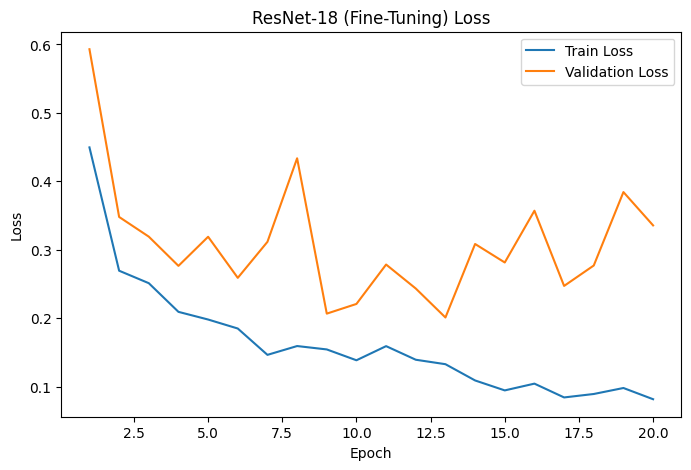

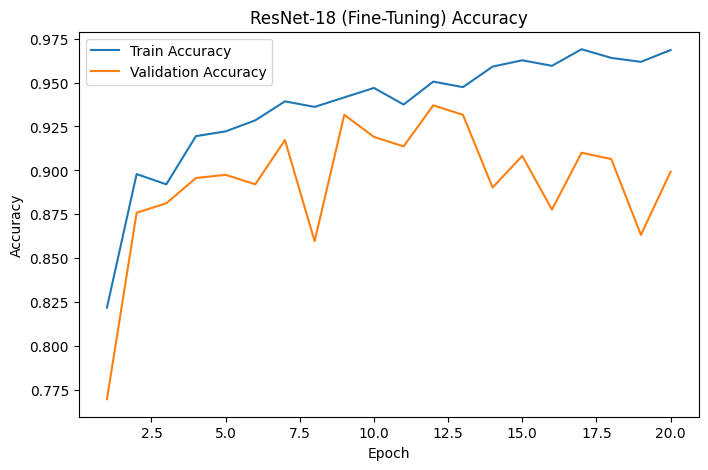

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs_resnet+1), finetune_train_losses, label="Train Loss")
plt.plot(range(1, num_epochs_resnet+1), finetune_val_losses,   label="Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("ResNet-18 (Fine-Tuning) Loss")
plt.legend(); plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs_resnet+1), finetune_train_accs, label="Train Accuracy")
plt.plot(range(1, num_epochs_resnet+1), finetune_val_accs,   label="Validation Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("ResNet-18 (Fine-Tuning) Accuracy")
plt.legend(); plt.show()

In [17]:
featext_train_losses, featext_train_accs = [], []
featext_val_losses,   featext_val_accs   = [], []
best_featext_acc = 0.0

for epoch in range(num_epochs_resnet):
    t_loss, t_acc = train_one_epoch(resnet_featext, train_loader, criterion_resnet, optimizer_featext, device)
    v_loss, v_acc = validate_one_epoch(resnet_featext, val_loader, criterion_resnet, device)

    featext_train_losses.append(t_loss)
    featext_train_accs.append(t_acc)
    featext_val_losses.append(v_loss)
    featext_val_accs.append(v_acc)

    if v_acc > best_featext_acc:
        best_featext_acc = v_acc
        torch.save(resnet_featext.state_dict(), "best_resnet_featext.pth")
        print(f"  -> Saved best model (val_acc: {v_acc:.4f})")

    print(f"Epoch [{epoch+1}/{num_epochs_resnet}]  "
          f"Train Loss: {t_loss:.4f}  Train Acc: {t_acc:.4f}  "
          f"Val Loss: {v_loss:.4f}  Val Acc: {v_acc:.4f}")

  -> Saved best model (val_acc: 0.8201)
Epoch [1/20]  Train Loss: 0.7244  Train Acc: 0.7001  Val Loss: 0.4797  Val Acc: 0.8201
  -> Saved best model (val_acc: 0.8345)
Epoch [2/20]  Train Loss: 0.4891  Train Acc: 0.8188  Val Loss: 0.4012  Val Acc: 0.8345
  -> Saved best model (val_acc: 0.8543)
Epoch [3/20]  Train Loss: 0.4182  Train Acc: 0.8390  Val Loss: 0.3828  Val Acc: 0.8543
  -> Saved best model (val_acc: 0.8597)
Epoch [4/20]  Train Loss: 0.4052  Train Acc: 0.8458  Val Loss: 0.3660  Val Acc: 0.8597
  -> Saved best model (val_acc: 0.8669)
Epoch [5/20]  Train Loss: 0.3948  Train Acc: 0.8471  Val Loss: 0.3270  Val Acc: 0.8669
  -> Saved best model (val_acc: 0.8813)
Epoch [6/20]  Train Loss: 0.3730  Train Acc: 0.8611  Val Loss: 0.3156  Val Acc: 0.8813
Epoch [7/20]  Train Loss: 0.3501  Train Acc: 0.8552  Val Loss: 0.3046  Val Acc: 0.8795
Epoch [8/20]  Train Loss: 0.3397  Train Acc: 0.8651  Val Loss: 0.3361  Val Acc: 0.8687
Epoch [9/20]  Train Loss: 0.3615  Train Acc: 0.8498  Val Loss: 0

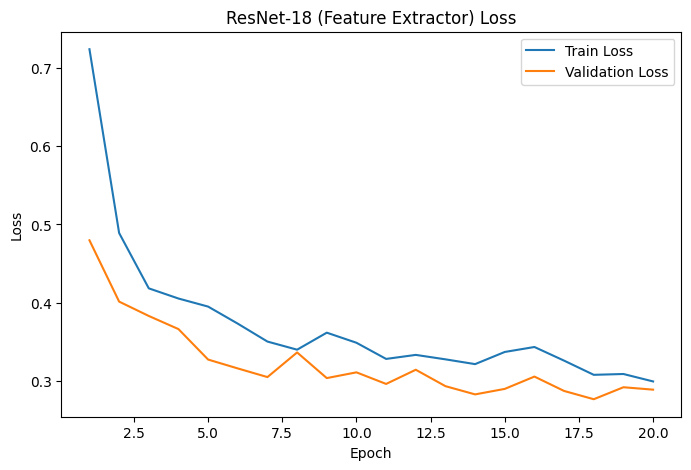

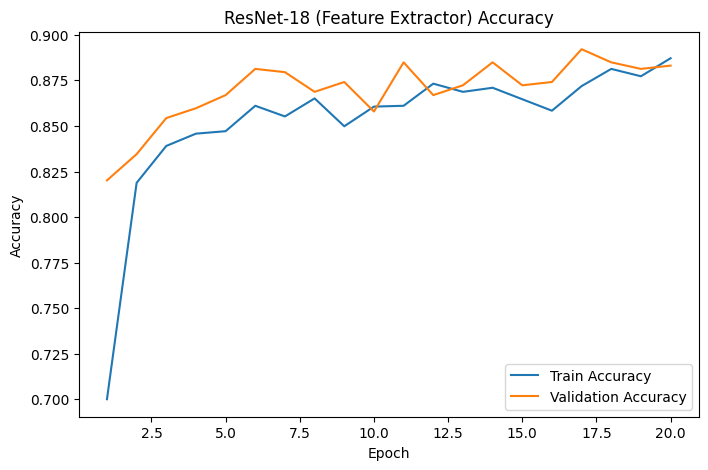

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs_resnet+1), featext_train_losses, label="Train Loss")
plt.plot(range(1, num_epochs_resnet+1), featext_val_losses,   label="Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("ResNet-18 (Feature Extractor) Loss")
plt.legend(); plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs_resnet+1), featext_train_accs, label="Train Accuracy")
plt.plot(range(1, num_epochs_resnet+1), featext_val_accs,   label="Validation Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("ResNet-18 (Feature Extractor) Accuracy")
plt.legend(); plt.show()

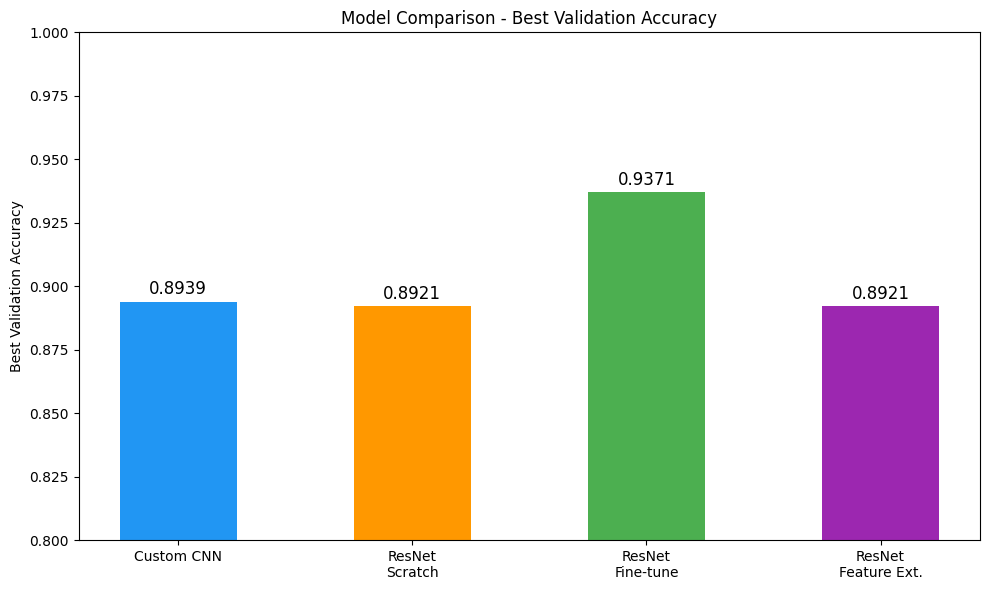

In [19]:
#determining the best training model

models = ['Custom CNN', 'ResNet\nScratch', 'ResNet\nFine-tune', 'ResNet\nFeature Ext.']
best_val_accs = [best_val_acc, best_scratch_acc, best_finetune_acc, best_featext_acc]
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']

plt.figure(figsize=(10, 6))
bars = plt.bar(models, best_val_accs, color=colors, width=0.5)

for bar, val in zip(bars, best_val_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f"{val:.4f}", ha='center', fontsize=12)

plt.ylim(0.8, 1.0)
plt.ylabel("Best Validation Accuracy")
plt.title("Model Comparison - Best Validation Accuracy")
plt.tight_layout()
plt.show()

---

# 3. **Evaluate models**

Here, you need to:

1.	evaluate the model (the best one you obtained in the above stage) on the appropriate set.


TEST SET EVALUATION (ResNet-18 Fine-Tune)
Accuracy:         0.9324
Macro F1:         0.9337
Cohen's Kappa:    0.8984
ROC-AUC (macro):  0.9859
MCC:              0.8984

              precision    recall  f1-score   support

      Normal       0.90      0.91      0.91       250
     Opacity       0.92      0.91      0.91       225
   Pneumonia       0.98      0.98      0.98       220

    accuracy                           0.93       695
   macro avg       0.93      0.93      0.93       695
weighted avg       0.93      0.93      0.93       695



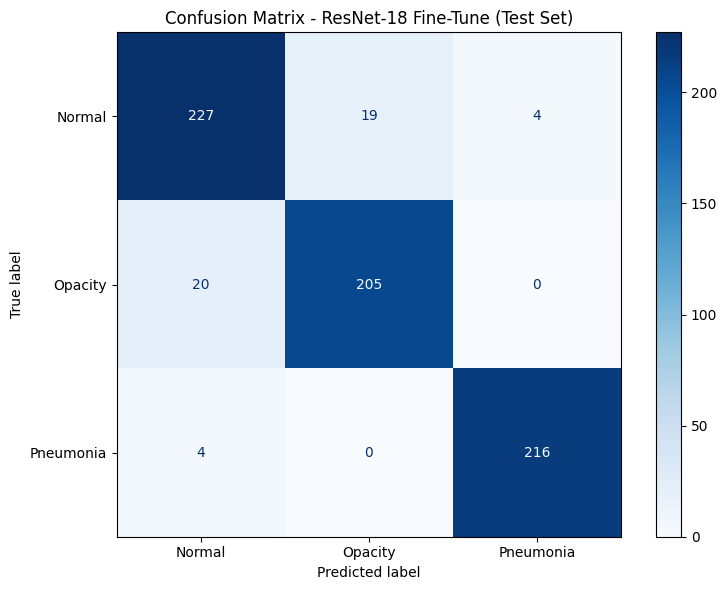

In [20]:
# Evaluating best model
resnet_finetune.load_state_dict(torch.load("best_resnet_finetune.pth"))
resnet_finetune.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet_finetune(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Metrics
acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='macro')
kappa = cohen_kappa_score(all_labels, all_preds)
roc_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
mcc = matthews_corrcoef(all_labels, all_preds)

print("=" * 40)
print("TEST SET EVALUATION (ResNet-18 Fine-Tune)")
print("=" * 40)
print(f"Accuracy:         {acc:.4f}")
print(f"Macro F1:         {f1:.4f}")
print(f"Cohen's Kappa:    {kappa:.4f}")
print(f"ROC-AUC (macro):  {roc_auc:.4f}")
print(f"MCC:              {mcc:.4f}")
print()

class_names = ["Normal", "Opacity", "Pneumonia"]
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("Confusion Matrix - ResNet-18 Fine-Tune (Test Set)")
plt.tight_layout()
plt.show()